# Project 0 — Exploratory Data Analysis (EDA)

**Why this notebook exists.** Every modeling project should start by **getting to know your data** before you reach for an algorithm. This notebook is the foundation that Projects 1-5 all build on. Don't skip it — most "model failures" downstream turn out to be **misunderstandings of the data**, not algorithm bugs.

**What we'll do here**
1. Load the dataset and inspect its shape, dtypes, and head/tail.
2. Check for **missing values**.
3. Understand **time coverage** — what dates does this dataset span?
4. Look at **player counts** — how many unique players, how many games each.
5. Look at **team-level structure** — rows per team, win/loss balance.
6. Plot **distributions** of the key numeric stats.
7. Inspect the **correlation structure** between stats.
8. Print **leaderboards** as a sanity check (do real-NBA names show up where they should?).
9. Document **quirks and limitations** of the dataset.

**One mindset shift for students**
> EDA is **not** about producing pretty plots. It's about *finding the things that will surprise you in modeling later*. Every chart below should answer either "what does this column mean?" or "is this column trustworthy?".


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

## 2. First look — load, shape, head

The very first thing to do with any new dataset is print its **shape**, the **head**, and the **dtypes**. You're answering: *how big is this thing, and what columns am I working with?*

In [2]:
DATA_PATH = "../data/nbadatabase_24_25 2/nbadatabase_24_25.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape:    {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"Memory:   {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
df.head()

Shape:    16,512 rows  ×  25 columns
Memory:   7.20 MB


,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,0.727,1,2,0.500,0,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,0.333,13,15,0.867,3,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,0.600,2,2,1.000,0,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,0.667,0,0,0.000,2,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,0.800,2,3,0.667,0,0,0,2,0,0,1,1,22,17.8,2024-10-22


In [3]:
df.dtypes

Player     object
Tm         object
Opp        object
Res        object
MP        float64
FG          int64
FGA         int64
FG%       float64
3P          int64
3PA         int64
3P%       float64
FT          int64
FTA         int64
FT%       float64
ORB         int64
DRB         int64
TRB         int64
AST         int64
STL         int64
BLK         int64
TOV         int64
PF          int64
PTS         int64
GmSc      float64
Data       object
dtype: object

**What we see**
- 25 columns, ~16.5k rows.
- Categorical/text columns: `Player`, `Tm`, `Opp`, `Res`, `Data`.
- Numeric stats: 20 columns covering shooting, rebounding, playmaking, and defense.

**Each row = one player in one game.** This is "long" format — if a game had 24 players appear, that's 24 rows.

### Feature dictionary — what every column means

If you've never seen a basketball box score before, this table is the one you'll come back to. The abbreviations are NBA-standard.

#### Identifiers (who, when, against whom)

| Column | Type | Meaning |
|---|---|---|
| `Player` | text | Player's full name (e.g., `Jayson Tatum`). |
| `Tm`     | text | The player's team, as a 3-letter code (`BOS` = Boston, `LAL` = Lakers, …). |
| `Opp`    | text | Opponent team, also as a 3-letter code. |
| `Res`    | text | Game result for the **player's team** — `W` (win) or `L` (loss). All players on the same team in the same game share this value. |
| `Data`   | text | **Date of the game**, formatted `YYYY-MM-DD`. The column name is a mislabel — it's not a "data" payload, it's a date. |

#### Playing time

| Column | Type | Meaning |
|---|---|---|
| `MP` | float | **Minutes Played**. Up to 48 in regulation, more if the game went to overtime. A typical starter plays 30–36; deep bench players log 5–10 (or are listed as DNP and don't appear in the dataset that night). |

#### Shooting — makes, attempts, and percentages

| Column | Type | Meaning |
|---|---|---|
| `FG`  | int   | **Field Goals Made** — every made basket from the floor (2-pointers and 3-pointers combined). Free throws are *not* counted here. |
| `FGA` | int   | **Field Goal Attempts** — every shot from the floor, made or missed. |
| `FG%` | float | **Field Goal Percentage** = `FG / FGA`. League average ~46%. Stored as `0.0` if the player didn't attempt any field goals (not `NaN`). |
| `3P`  | int   | **Three-Pointers Made**. A subset of `FG` — every `3P` is also a `FG`. |
| `3PA` | int   | **Three-Point Attempts**. Subset of `FGA`. |
| `3P%` | float | **Three-Point Percentage** = `3P / 3PA`. League average ~36%. Stored as `0.0` if no three-point attempts. |
| `FT`  | int   | **Free Throws Made**. Awarded after fouls; each is worth 1 point. |
| `FTA` | int   | **Free Throw Attempts**. |
| `FT%` | float | **Free Throw Percentage** = `FT / FTA`. League average ~78%. Stored as `0.0` if no free-throw attempts. |

#### Rebounding

| Column | Type | Meaning |
|---|---|---|
| `ORB` | int | **Offensive Rebounds** — the player rebounded a missed shot by **his own team**, giving his team a fresh possession. Big-man stat. |
| `DRB` | int | **Defensive Rebounds** — the player rebounded a missed shot by the **opponent**, ending the opponent's possession. |
| `TRB` | int | **Total Rebounds** = `ORB + DRB` exactly. Redundant with the two above (perfect multicollinearity — pick one or the other in a model, never all three). |

#### Playmaking and defense

| Column | Type | Meaning |
|---|---|---|
| `AST` | int | **Assists** — passes that lead directly to a teammate's made basket. Point-guard stat. |
| `STL` | int | **Steals** — the player took the ball from an opponent, ending their possession. |
| `BLK` | int | **Blocks** — the player rejected an opponent's shot attempt. |
| `TOV` | int | **Turnovers** — the player lost possession by mistake (bad pass, traveled, dribbled off foot, etc.). Lower is better. |
| `PF`  | int | **Personal Fouls** committed by the player. 6 fouls = ejected for the rest of the game. |

#### Scoring and overall performance

| Column | Type | Meaning |
|---|---|---|
| `PTS`  | int   | **Total Points Scored** in the game. Mathematically: `PTS = 2·(FG − 3P) + 3·(3P) + FT`. Because `PTS` is exactly determined by `FG`, `3P`, and `FT`, **never use those three as features when the target is `PTS`** (data leakage — see Projects 1 and 3). |
| `GmSc` | float | **Game Score** — John Hollinger's single-number summary of overall game performance. A weighted combination of every box-score stat (rewards points, rebounds, assists, steals, blocks; penalises misses, turnovers, fouls). Rough scale: **~10 = average game, 20+ = great game, 40+ = legendary**. Like `PTS`, it's a derived stat — using it as a feature alongside its raw inputs leaks the answer. |

⚠️ **First quirk to flag.** The column called `Data` is **actually the date of the game** — not a "data" payload. We'll convert it to a real datetime in the next section.

## 3. Missing-value check

Always do this before modeling. Many algorithms break on `NaN`.

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

No missing values — the dataset is clean. (Heads-up for projects that compute percentages: `FG%`, `3P%`, `FT%` will be **0.0** when a player attempted nothing of that type, which is a substitute for missingness.)

## 4. Time coverage

### Why we care about this section

Before we touch any model, we need to answer two boring-but-critical questions about the **temporal shape** of the data. Skipping this step is one of the most common ways data-science projects quietly go wrong.

**1. What date range does this dataset actually cover?**
- It tells us **how much history** we have to work with. Project 3 (next-game forecasting) needs to compute "last-5-games" rolling features for each player — if the dataset only spans a few weeks, those rolling windows will be mostly empty for everyone.
- It tells us **what conclusions are honest** to draw. A half-season snapshot can't support claims like *"this player was the season's most efficient scorer"* — only *"as of February"*.
- It tells us whether the dataset is **stale** for the question we're asking (is this from 2024-25 or 2018-19?).

**2. Are there missing dates or weird scheduling gaps?**
- If a chunk of dates is suspiciously empty, the **scraper probably failed there** — much better to discover this now than during modeling, when broken results would be harder to trace back.
- The number of games per night is also a **plausibility check**: real NBA schedules average ~6–8 games per night with weekend spikes. If we saw 50 games on a single date, the data is probably duplicated. If every date had exactly 1 game, we'd be looking at a single team's schedule, not the whole league.

**Bottom line:** these two checks take 30 seconds to write and can save hours of debugging downstream. Always do them on any time-stamped dataset.

In [5]:
df["Data"] = pd.to_datetime(df["Data"])
print(f"Date range:  {df['Data'].min().date()}  →  {df['Data'].max().date()}")
print(f"Distinct game-dates:  {df['Data'].nunique()}")

Date range:  2024-10-22  →  2025-02-07
Distinct game-dates:  105


**What this tells us**
- Coverage: roughly Oct 22, 2024 → early Feb 2025 — about a **half season** (mid-season snapshot, not the full year).

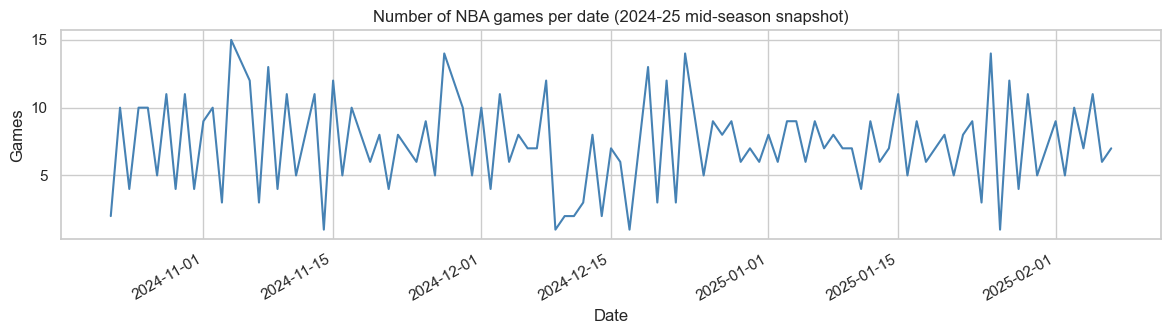

count    105.0
mean       7.3
std        3.3
min        1.0
25%        5.0
50%        7.0
75%       10.0
max       15.0
Name: matchup, dtype: float64

In [13]:
# Build an unordered matchup key so BOS-NYK and NYK-BOS collapse to one game
df["matchup"] = df[["Tm", "Opp"]].apply(lambda r: "-".join(sorted(r)), axis=1)

games_per_date = df.groupby("Data")["matchup"].nunique()

fig, ax = plt.subplots(figsize=(12, 3.5))
games_per_date.plot(ax=ax, color="steelblue", lw=1.5)
ax.set_title("Number of NBA games per date (2024-25 mid-season snapshot)")
ax.set_ylabel("Games"); ax.set_xlabel("Date")
plt.tight_layout(); plt.show()

games_per_date.describe().round(1)

**What this tells us**
- The league played anywhere from **1 to 15 games on a single date**, averaging ~7 per night.
- The big spikes (10–15 games) are the league's full-slate weekend nights; the dips (1–3 games) are quiet weekday or holiday slots.
- No huge gaps that would suggest broken scraping or missing dates.

## 5. Players — how many, and how many games each?

### Why we care about this section

Now we shift focus from *time* to *people*. Two related questions, and both shape modeling decisions later.

**1. How many unique players are in the dataset?**
- Sanity check on the dataset's **scope**. The NBA has 30 teams × ~17 active players ≈ 510 names per season (a bit more with two-way contracts and 10-day signings). If we see ~500–600 unique players, the dataset is league-wide. If we see 17, we accidentally have one team. If we see 5, we have a tiny sample and most of these projects can't run.

**2. How many games has each player played?**
- This is the most **modeling-critical question** in the whole EDA. Every per-player aggregate downstream (season-average PTS, average True Shooting %, residual leaderboards) is **only as trustworthy as the number of games behind it**. A player with 2 games who happened to drop 30 points each night will look like the league's best scorer — but it's pure small-sample noise.
- The shape of this distribution tells us how to set the **minimum-games filter** that Projects 1, 2, and 4 all rely on. Set it too low and your leaderboards fill with fluky 5-game samples; set it too high and you throw away meaningful players.
- It also reveals the league's roster churn: **10-day contracts, two-way players, mid-season call-ups** all show up as the long tail of "appeared in only a few games."

**Bottom line:** the histogram below isn't a curiosity — it's the chart we'll point to every time we justify a `MIN_GAMES = 15` (or 20) filter elsewhere in the project.

Unique players: 562


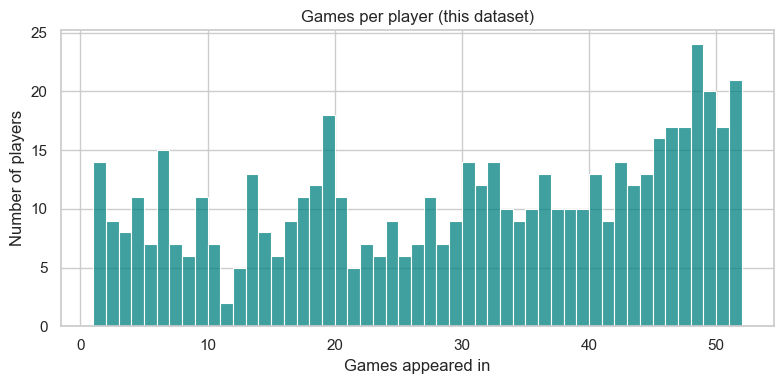

count    562.0
mean      29.4
std       15.5
min        1.0
25%       17.0
50%       31.0
75%       44.0
max       52.0
Name: games, dtype: float64

In [14]:
print(f"Unique players: {df['Player'].nunique()}")

games_per_player = df.groupby("Player").size().rename("games")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(games_per_player, bins=51, ax=ax, color="teal")
ax.set_title("Games per player (this dataset)")
ax.set_xlabel("Games appeared in"); ax.set_ylabel("Number of players")
plt.tight_layout(); plt.show()

games_per_player.describe().round(1)

**Interpretation**

Total: **562 unique players** in the dataset, which matches expectations for a league-wide snapshot (30 teams × ~17 active players ≈ 510, plus two-way and 10-day contracts).

Reading the histogram from left to right:

| Range | Count | Who these players are |
|---|---|---|
| 1–5 games | ~49 | Fringe roster: 10-day contracts, two-way call-ups, end-of-bench guys, mid-season cuts. The leftmost bar (~14 of them played just 1 game). |
| 6–20 games | ~141 | Deep-bench rotation, injury fill-ins, traded players splitting their season. |
| 21–40 games | ~192 | Steady role players — usually in the rotation, occasionally rested or DNP. |
| 41–55 games | ~180 | The **rotation regulars** who play almost every night. This is where the histogram peaks. |

**Key takeaways**
- The dataset is **not** dominated by fringe players — the bulk (~370 of 562, two-thirds) have played 21+ games. Median is **31 games**.
- But the **left tail is real**: ~49 players played 5 or fewer games. Their per-player averages will be wildly noisy.
- This is why Projects 1, 2, and 4 all set a **`MIN_GAMES = 15` or `20` filter** — it drops the noisy left tail (~95 players) and keeps the ~470 with stable enough samples to trust.

## 6. Teams — games played and win/loss balance

### Why we care about this section

Sections 4 and 5 looked at *time* and *players*. This section looks at the **team** dimension — and there are three things we want to confirm before any modeling.

**1. Are all 30 teams present?**
- The NBA has exactly **30 franchises**. If we count fewer, the dataset is missing entire teams (a scraping bug). If we count more, something weird like duplicate codes (e.g., `BRK` and `BKN` both appearing for Brooklyn) is happening.

**2. Did each team play roughly the same number of games?**
- The NBA schedule is balanced — every team plays 82 games per season, give or take rest days and back-to-backs. In a half-season snapshot we'd expect each team to have played around the **same number of games (~50)**, within a small spread (a few games). If one team is wildly off, either the scraper missed a chunk of their schedule or there's a duplicate.

**3. Does the win/loss split make basketball sense?**
- League-wide, **wins must equal losses** — every game has exactly one winner and one loser. If we sum all rows by `Res`, the totals should be very close.
- Per team, the **win rate** is a quick reality check on standings: do the league's elite teams (OKC, Cleveland, Boston, etc., as of February 2025) appear at the top? Do the rebuilders appear at the bottom? If not, the `Res` column is mislabeled.

**Why this matters for modeling**
- Knowing the **team-strength landscape** gives context for any per-game prediction. If Project 3 is forecasting points for a player about to face the league's #1 defense, you'd expect their score to dip — and you'd want to add **opponent strength** as a feature.
- The W/L column is also the natural target for any future "predict the game outcome" classification project (a strong fit for Project 6 if you wanted to extend the lineup).

Teams in dataset: 30

Most games:
Tm
ORL    53
ATL    52
BRK    52
CHI    52
CLE    52
Name: Data, dtype: int64

Fewest games:
Tm
MIA    50
UTA    50
CHO    49
LAL    49
SAS    49
Name: Data, dtype: int64


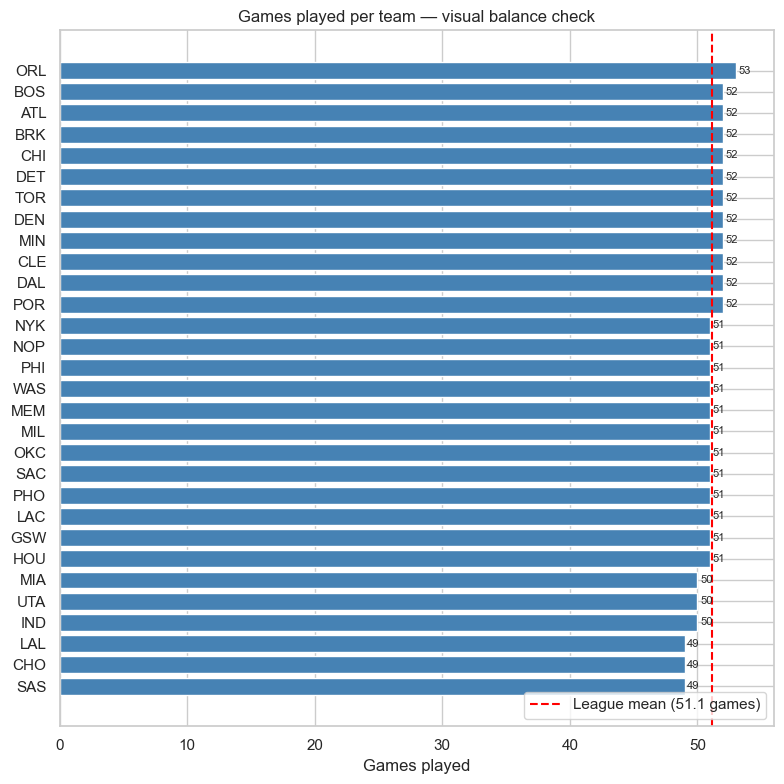

In [22]:
# Each team plays at most one game per date, so the count of unique dates per team
# = the number of games that team played.
games_per_team = df.groupby("Tm")["Data"].nunique().sort_values(ascending=False)

print(f"Teams in dataset: {len(games_per_team)}")
print("\nMost games:"); print(games_per_team.head(5))
print("\nFewest games:"); print(games_per_team.tail(5))

games_sorted = games_per_team.sort_values()
mean_games   = games_per_team.mean()

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(games_sorted.index, games_sorted.values, color="steelblue")
ax.axvline(mean_games, color="red", linestyle="--",
           label=f"League mean ({mean_games:.1f} games)")
for tm, g in games_sorted.items():
    ax.text(g + 0.2, tm, str(g), va="center", fontsize=8)
ax.set_xlim(0, games_sorted.max() + 3)
ax.set_xlabel("Games played")
ax.set_title("Games played per team — visual balance check")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Interpretation**

**Games-per-team chart**
- All **30 teams present** — passes the basic completeness check.
- Games played range from **49 (LAL, CHO, SAS) to 53 (ORL)** — a tight spread of just 4 games. That's exactly what we'd expect for a balanced NBA schedule midway through the season; the small differences reflect scheduling quirks (back-to-backs, rest days, road trips). No team is a clear outlier, so no scraping concerns.
- League mean: **~51 games** per team — consistent with a snapshot taken in early February, about 60% of the way through an 82-game season.

Res,L,W,win_rate
Tm,,,
CLE,10,42,0.807692
OKC,10,41,0.803922
BOS,16,36,0.692308
MEM,16,35,0.686275
NYK,17,34,0.666667
DEN,19,33,0.634615
HOU,19,32,0.627451
LAL,19,30,0.612245
IND,21,29,0.580000


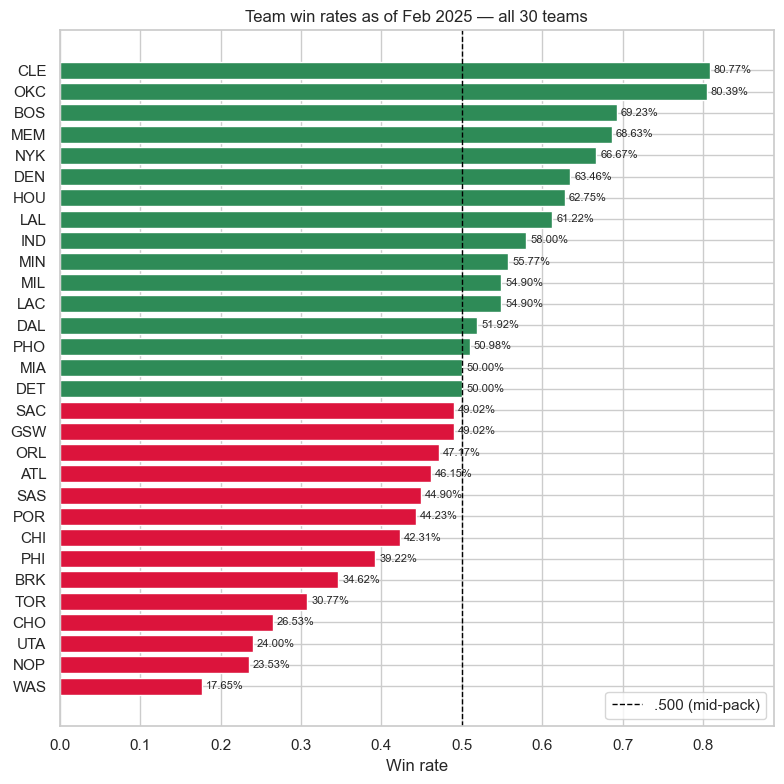

In [25]:
# Each row is a player-game, so the same game appears once per player on the roster.
# Deduplicate to one row per (Tm, Date) before counting W/L — otherwise rotation size
# would skew the totals (more bench players in losses → fewer in wins).
team_games = df.drop_duplicates(["Tm", "Data"])[["Tm", "Data", "Res"]]

wl = (team_games.groupby(["Tm", "Res"]).size().unstack(fill_value=0)
                .assign(win_rate=lambda d: d["W"] / (d["W"] + d["L"]))
                .sort_values("win_rate", ascending=False))
display(wl.head(10))

wl_all = wl.sort_values("win_rate")  # ascending for the bar chart

colors = ["crimson" if wr < 0.5 else "seagreen" for wr in wl_all["win_rate"]]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(wl_all.index, wl_all["win_rate"], color=colors)
ax.axvline(0.5, color="black", linestyle="--", lw=1, label=".500 (mid-pack)")
for tm, wr in wl_all["win_rate"].items():
    ax.text(wr + 0.005, tm, f"{wr:.2%}", va="center", fontsize=8)
ax.set_xlim(0, max(wl_all["win_rate"]) + 0.08)
ax.set_xlabel("Win rate")
ax.set_title("Team win rates as of Feb 2025 — all 30 teams")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Interpretation**

**Win-rate chart**
- The standings make basketball sense as of February 2025:
  - **Top of the league**: Cleveland (~81%), OKC (~80%), Boston (~69%), Memphis, NYK — the season's elite teams.
  - **Bottom**: Washington (~18%), New Orleans, Utah, Charlotte, Toronto — rebuilders and lottery teams.
- Roughly **half the league sits above the .500 dashed line** and half below — exactly what we'd expect since wins and losses are zero-sum across the league.

## 7. Distributions of the key numeric stats

A grid of histograms gives you a one-glance overview of the most important variables. Look at each one and ask: *is this shape what I'd expect?*

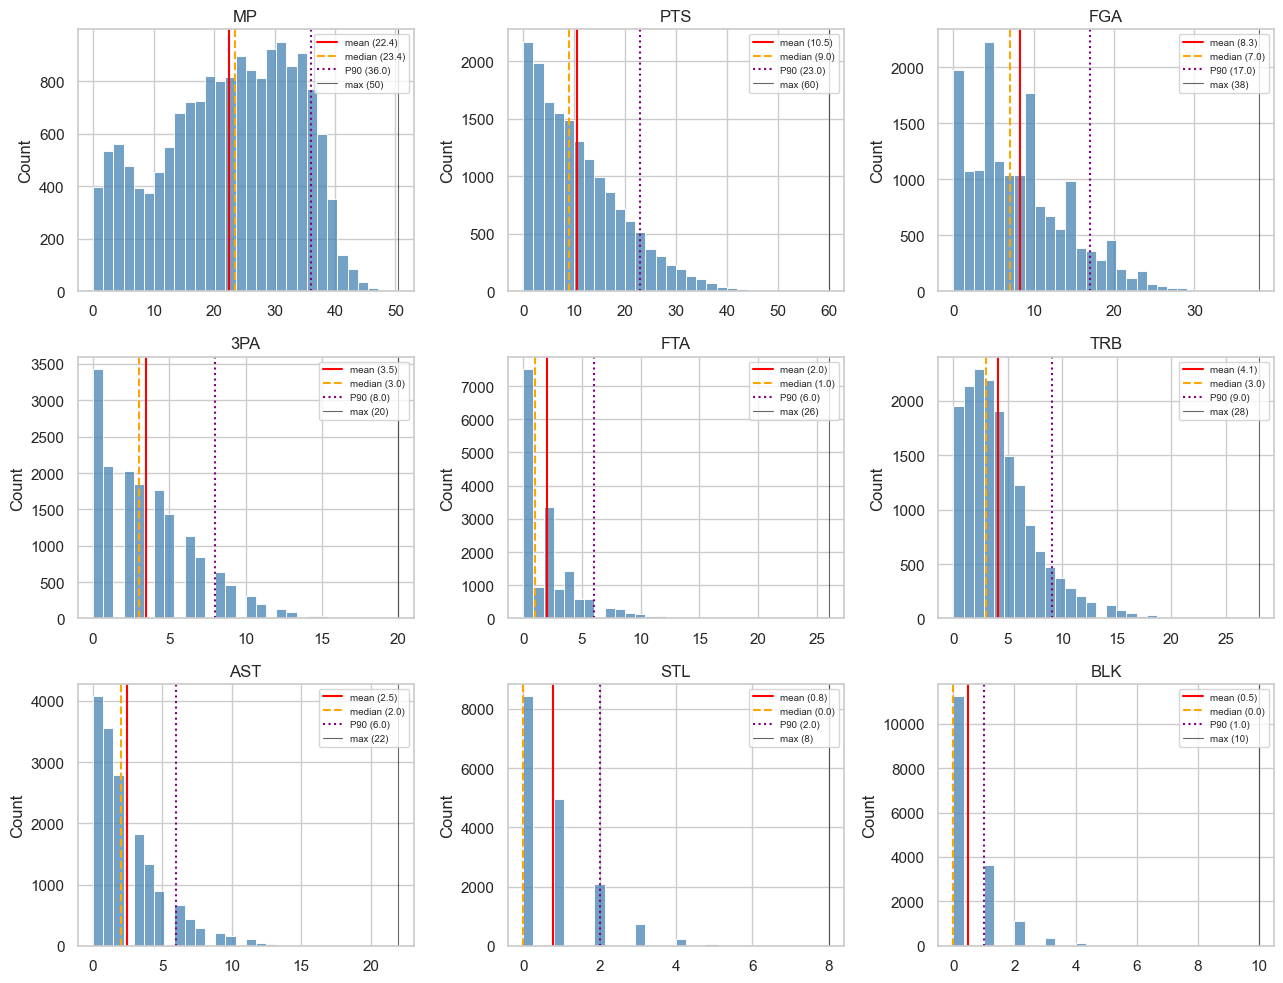

In [26]:
key_stats = ["MP", "PTS", "FGA", "3PA", "FTA", "TRB", "AST", "STL", "BLK"]

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, key_stats):
    s = df[col]
    sns.histplot(s, bins=30, ax=ax, color="steelblue")

    mean_v   = s.mean()
    median_v = s.median()
    p90_v    = s.quantile(0.9)
    max_v    = s.max()

    ax.axvline(mean_v,   color="red",    linestyle="-",  lw=1.5, label=f"mean ({mean_v:.1f})")
    ax.axvline(median_v, color="orange", linestyle="--", lw=1.5, label=f"median ({median_v:.1f})")
    ax.axvline(p90_v,    color="purple", linestyle=":",  lw=1.5, label=f"P90 ({p90_v:.1f})")
    ax.axvline(max_v,    color="black",  linestyle="-",  lw=0.8, alpha=0.6, label=f"max ({max_v:.0f})")

    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend(fontsize=7, loc="upper right")

plt.tight_layout(); plt.show()

**Reading each distribution**

| Stat | Mean | Median | P90 | Max | % zero | Reasonable? |
|---|---|---|---|---|---|---|
| `MP`  | 22.4 | 23.4 | 36 | 50 | 0% | ✅ Bell-ish around 22 min, capped near 48 (regulation) with overtime stretching to 50. Matches the typical mix of 30-min starters + 15-min bench. |
| `PTS` | 10.5 | 9    | 23 | 60 | 12% | ✅ Right-skewed, median 9, max 60 (Giannis vs DET) — matches reality. The 12% zeros are bench players who took 0 shots. |
| `FGA` | 8.3  | 7    | 17 | 38 | 6%  | ✅ Right-skewed; only 6% take zero shots (pure defenders/big men in low-minute roles). |
| `3PA` | 3.5  | 3    | 8  | 20 | 21% | ✅ The 21% zeros are traditional bigs (Sabonis, Adebayo) who don't shoot threes. P90 of 8 attempts matches modern volume shooters. |
| `FTA` | 2.0  | 1    | 6  | 26 | 45% | ✅ Almost half of player-games have zero free throws — typical for spot-up shooters and bench rotation guys who don't draw fouls. |
| `TRB` | 4.1  | 3    | 9  | 28 | 12% | ✅ P90 of 9 is the rotation-big threshold; the max of 28 is in the historic-game range (Sabonis/Wemby territory). |
| `AST` | 2.5  | 2    | 6  | 22 | 25% | ✅ A quarter of player-games have zero assists (off-ball wings, finishing centers). P90 of 6 is the playmaker line. |
| `STL` | 0.8  | 0    | 2  | 8  | 51% | ✅ Half of all player-games have zero steals — steals are inherently rare events. Max of 8 is a great defensive game. |
| `BLK` | 0.5  | 0    | 1  | 10 | 68% | ✅ The rarest stat: 68% zeros. Only big men block consistently. Max of 10 is historic. |

**Key takeaways for modeling**

1. **Heavy right-skew** for every counting stat (`PTS`, `FGA`, `3PA`, `FTA`, `TRB`, `AST`, `STL`, `BLK`). Most player-games are modest; superstar games are rare outliers in the long right tail.
2. **`STL` and `BLK` are mostly zero** (51% and 68% respectively). Treating them as continuous Gaussian variables is wrong — they're closer to count distributions (Poisson-like). Linear regression will struggle; **tree-based models handle them naturally**.
3. **`MP` is the only roughly-symmetric one**, capped at ~48 minutes by the rules of basketball. It's also the most useful "exposure" feature — almost every other stat scales with minutes played.
4. **The skew matters for choice of metric.** RMSE will be dominated by the rare extreme games; MAE is more robust. Project 3 reports both.
5. **The skew also matters for clustering** (Project 4): without scaling, `MP` and `PTS` would dominate the distance metric over `STL`/`BLK`. That's why Project 4 uses `StandardScaler` — non-negotiable.

**Bottom line:** every distribution looks like real NBA data. No suspicious bumps, no hard caps in weird places, no impossible values. The dataset passes the plausibility test.

## 8. Correlation structure

### Why we care about this section

A correlation matrix shows how every pair of numeric columns moves together. We compute it before modeling for **three concrete reasons**:

**1. Spot redundant features (multicollinearity).**
- If two features carry essentially the same information (correlation > ~0.95), keeping both adds noise without information. For linear models, near-perfect correlation breaks the math (coefficients become unstable). For tree models, it's less harmful, but interpretability suffers — feature importance gets split arbitrarily between the redundant pair.

**2. Catch target leakage early.**
- If a candidate "feature" is mechanically derived from the target (like `FG` is from `PTS`), it'll show up as `r ≈ 0.97`. That's a **flashing red flag** that you'd be cheating in the model. Better to find this in EDA than after weeks of work on a "magically accurate" model.

**3. Confirm intuition (or surprise yourself).**
- We *expect* shooting volume to track scoring (`FGA` ↔ `PTS`). If it doesn't, the data is broken.
- We *don't expect* defensive stats to track offensive ones strongly (`BLK` ↔ `3P`). If they do, something weird is going on.

**Bottom line:** the heatmap below is a feature-selection cheat sheet. Bright red squares = "use one or the other, not both". Pale squares = "these features carry independent signal".

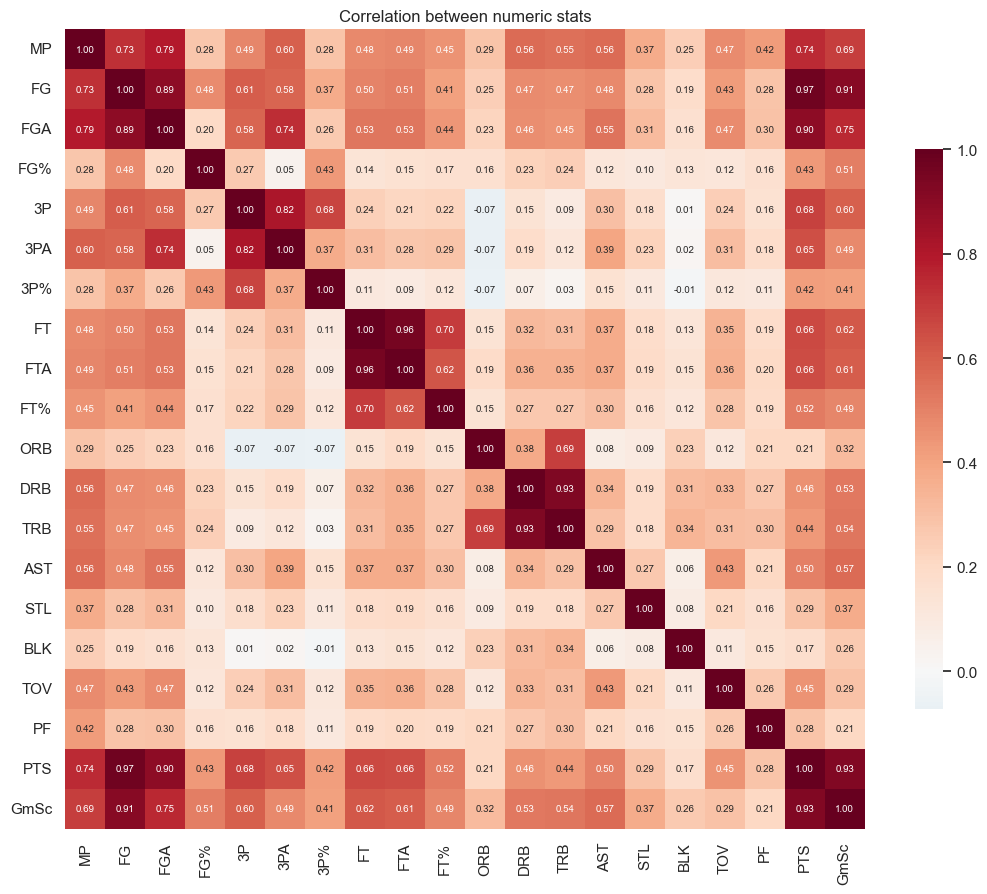

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            square=True, cbar_kws={"shrink": 0.7}, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Correlation between numeric stats")
plt.tight_layout(); plt.show()

### Takeaways from the heatmap

#### Strongest correlations — the red squares to act on

| Pair | r | Why so high | Action |
|---|---|---|---|
| `FG` ↔ `PTS`     | **+0.97** | `PTS = 2·(FG−3P) + 3·3P + FT` — `FG` mechanically determines most of `PTS`. | **Target leakage.** Drop `FG`, `3P`, `FT` whenever predicting `PTS` (Projects 1, 3). |
| `FT` ↔ `FTA`     | **+0.96** | Free-throw makes are essentially attempts × ~78%. | Use one, not both, in linear models. |
| `DRB` ↔ `TRB`    | **+0.93** | `TRB = ORB + DRB`, and DRB dominates the sum. | Pure collinearity — drop `TRB` if you keep `ORB` + `DRB`. |
| `PTS` ↔ `GmSc`   | **+0.93** | `GmSc` is a weighted summary of `PTS` and other stats. | Don't mix `GmSc` with raw box-score features — it leaks. |
| `FGA` ↔ `PTS`    | **+0.90** | More attempts → more points (with normal conversion). | This is the **legitimate** scoring signal — keep it. |
| `3P` ↔ `3PA`     | **+0.82** | Makes track attempts at ~36% conversion. | Use one in linear models; both fine in tree models. |
| `MP` ↔ `FGA`     | **+0.79** | More minutes → more shot opportunities. | `MP` is the fundamental "exposure" feature. |

#### Weakest correlations — surprising independence

| Pair | r | What this tells us |
|---|---|---|
| `3P` ↔ `BLK`     | +0.01 | Three-point shooters and shot-blockers are almost completely different player types. |
| `3PA` ↔ `ORB`    | −0.07 | Volume three-shooters don't crash the offensive boards — by design (they're hanging back for transition defense). |
| `AST` ↔ `BLK`    | +0.06 | Playmakers (guards) and shot-blockers (centers) live on opposite ends of the position spectrum. |

These near-zero correlations are exactly why **clustering works** (Project 4) — the player-style space has multiple **independent axes**: shooting, playmaking, rim defense, rebounding. If everything were correlated with `MP`, all players would look the same.

#### Concrete modeling rules (taken from this heatmap)

1. **Predicting `PTS`?** Exclude `FG`, `3P`, `FT`, all percentages, and `GmSc`. Keep `FGA`, `3PA`, `FTA`, `MP`, and the rest. (Used in Projects 1 and 3.)
2. **Predicting `FG%` or `TS%`?** Exclude `PTS`, `FG`, `3P`, `FT` and `GmSc`. (Used in Project 2.)
3. **Clustering?** Drop `TRB` (keep `ORB` + `DRB`). Drop one of `FG`/`FGA` and one of `3P`/`3PA` and one of `FT`/`FTA`. Always scale features. (Used in Project 4.)
4. **Anomaly detection?** Use the raw counts directly — Isolation Forest doesn't care about correlation, and combinations are often what makes a game weird. (Used in Project 5.)

**Bottom line:** the heatmap is doing real work — it tells us *which features to drop* before any model is trained. Skipping this step is how leakage bugs sneak into a project.

## 9. Leaderboards — does this look like real NBA?

### Why we care about this section

Leaderboards are the **single best EDA sanity check** on a sports / named-entity dataset. Why?

**1. Statistics can lie. Names can't.**
- Distributions, means, and correlations can all "look right" even when the data is wrong (e.g., wrong year, swapped team codes, a corrupted scrape). But if the league's leading scorer comes back as **"Joe Random"** with 30 PPG, you know instantly that something is broken — even if every chart so far looked plausible.

**2. It validates the column meanings.**
- The stat dictionary says `AST` = assists. The leaderboards prove it: if Trae Young, Jokic, Cade Cunningham, and LeBron sit at the top of `AST`, the column really *is* assists. If kids came out as the assist leaders, `AST` would actually be measuring something else.

**3. It reveals position roles for free.**
- Guards should dominate `AST` and `STL`. Centers should dominate `TRB` and `BLK`. If the leaderboards confirm this **without us telling the model anything about positions**, then position information is *implicit in the box score* — which is why clustering (Project 4) can rediscover positions from raw stats alone.

**4. Portfolio impact.**
- A notebook with **recognizable names** is dramatically more compelling than one with abstract row IDs. Showing your model identifies SGA, Giannis, and Jokic as elite is exactly what a portfolio reviewer wants to see.

**Bottom line:** five lines of `groupby` give you a quick reality check that no other EDA step provides. Always do this on entity-keyed datasets (players, customers, products).

Qualified players (GP >= 20): 383

— Top 10 scorers (average per game) —
                         GP    PPG
Player                            
Shai Gilgeous-Alexander  50  32.44
Giannis Antetokounmpo    42  31.62
Nikola Jokić             46  29.70
Luka Dončić              22  28.14
LaMelo Ball              32  28.03
Tyrese Maxey             44  27.84
Anthony Edwards          51  27.22
Kevin Durant             39  26.92
Jayson Tatum             49  26.55
Devin Booker             46  26.41

— Top 10 rebounders (average per game) —
                       GP    RPG
Player                          
Domantas Sabonis       48  14.27
Karl-Anthony Towns     46  13.61
Nikola Jokić           46  12.70
Ivica Zubac            49  12.65
Giannis Antetokounmpo  42  12.33
Isaiah Hartenstein     31  11.97
Walker Kessler         40  11.90
Anthony Davis          42  11.86
Victor Wembanyama      43  10.91
Alperen Sengun         35  10.46

— Top 10 playmakers (average per game) —
                   GP    AP

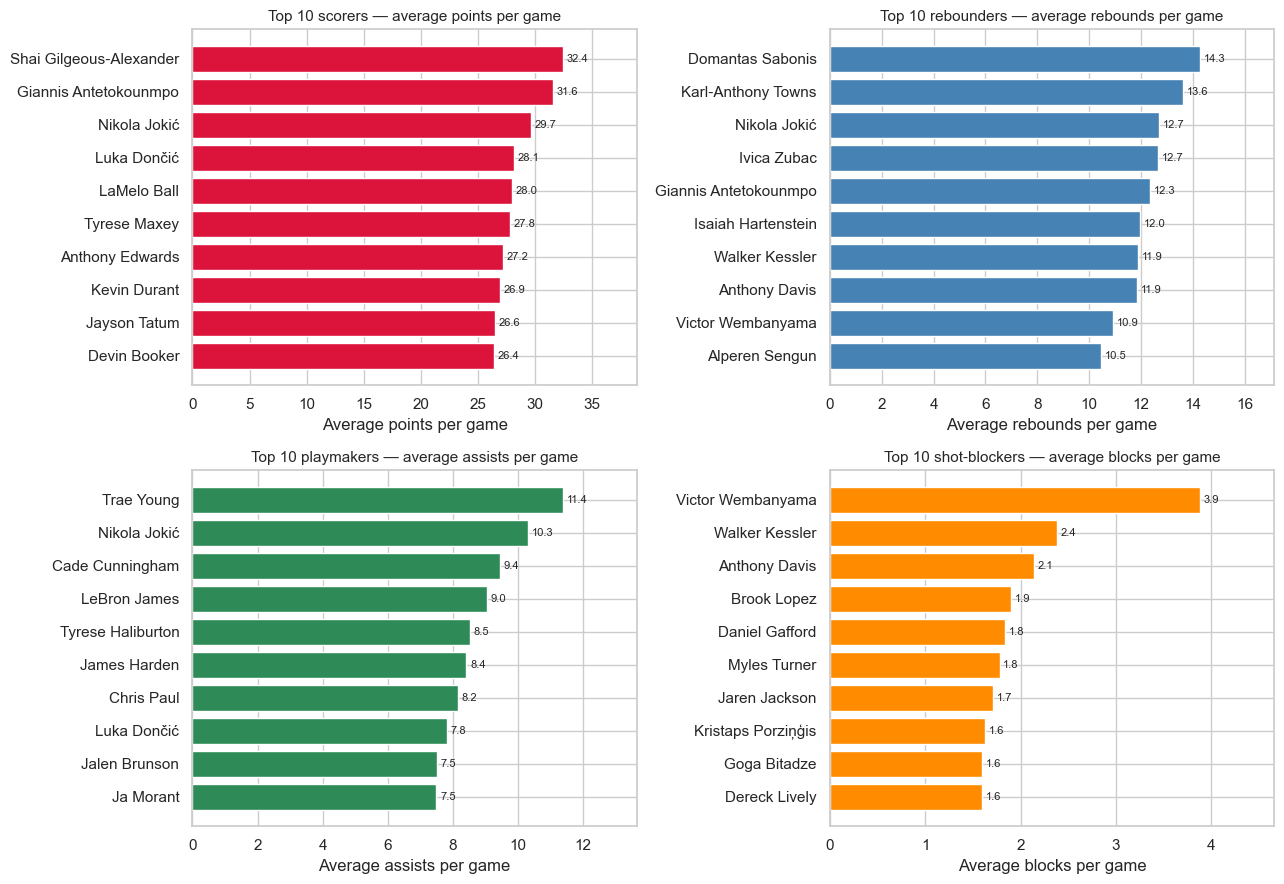

In [28]:
MIN_GAMES = 20

# Note: these are per-game averages across each player's qualified games,
# NOT single-game peaks.
per_player = (df.groupby("Player")
                .agg(GP =("PTS", "size"),
                     PPG=("PTS", "mean"),
                     RPG=("TRB", "mean"),
                     APG=("AST", "mean"),
                     SPG=("STL", "mean"),
                     BPG=("BLK", "mean"))
                .query("GP >= @MIN_GAMES")
                .round(2))

print(f"Qualified players (GP >= {MIN_GAMES}): {len(per_player)}")
print()

for stat, label in [("PPG", "scorers"), ("RPG", "rebounders"),
                    ("APG", "playmakers"), ("BPG", "shot-blockers")]:
    print(f"— Top 10 {label} (average per game) —")
    print(per_player.sort_values(stat, ascending=False).head(10)[["GP", stat]])
    print()

# Visualise the four leaderboards
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_specs = [
    ("PPG", "Top 10 scorers — average points per game",      "Average points per game",   "crimson"),
    ("RPG", "Top 10 rebounders — average rebounds per game", "Average rebounds per game", "steelblue"),
    ("APG", "Top 10 playmakers — average assists per game",  "Average assists per game",  "seagreen"),
    ("BPG", "Top 10 shot-blockers — average blocks per game","Average blocks per game",   "darkorange"),
]
for ax, (stat, title, xlabel, color) in zip(axes.flat, plot_specs):
    top = per_player.sort_values(stat, ascending=False).head(10)[stat]
    ax.barh(top.index[::-1], top.values[::-1], color=color)
    for name, v in zip(top.index[::-1], top.values[::-1]):
        ax.text(v + max(top.values) * 0.01, name, f"{v:.1f}", va="center", fontsize=8)
    ax.set_xlim(0, max(top.values) * 1.2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
plt.tight_layout(); plt.show()

### Interpretation — does the data pass?

**Yes — every leaderboard makes basketball sense as of February 2025.**

**Scoring (PPG):** SGA (32.4), Giannis (31.6), Jokic (29.7), Doncic (28.1), LaMelo, Maxey, Edwards, Durant, Tatum, Booker — exactly the names you'd expect at the top of the league mid-season.

**Rebounding (RPG):** Sabonis (14.3), KAT (13.6), Jokic (12.7), Zubac (12.6), Giannis (12.3) — dominated by big men, as expected. Wemby and Anthony Davis on the list too. ✅

**Playmaking (APG):** Trae Young (11.4) leads, then Jokic (10.3), Cade, LeBron, Haliburton, Harden, Chris Paul, Brunson — all elite playmakers. ✅

**Shot-blocking (BPG):** Wemby (3.9) is far ahead — matches reality, he was *the* defensive headline of the season. Then Walker Kessler, Anthony Davis, Brook Lopez, Daniel Gafford. All centers / rim-protectors. ✅

### What the cross-board appearances tell us

- **Jokic appears on PPG, RPG, *and* APG** — the only player to do that. This is exactly his historic offensive profile (top-3 in scoring, rebounding, *and* playmaking simultaneously is essentially unprecedented).
- **Giannis on PPG + RPG** — the modern point-forward archetype.
- **Wemby on RPG + BPG** — classic two-way center.
- **Anthony Davis on RPG + BPG** — same pattern.

This cross-board overlap is **strong evidence the dataset is internally consistent** — players who are great in one category according to common knowledge also lead the relevant other categories in the data. If the columns were mislabeled, this overlap pattern would not hold.

### Caveats worth noticing

- **Luka Dončić has only 22 GP** — he was injured for stretches of the early season. He still clears the `MIN_GAMES = 20` filter, but his averages are based on a smaller sample than the others. **`MIN_GAMES` is necessary but not sufficient** — always glance at the `GP` column on a leaderboard.
- **Per-game stats reward usage, not efficiency.** SGA leads PPG partly because OKC plays him 34 minutes a night with high usage. Project 1 (residual analysis) uses a different lens — *points above expected* — to find efficiency-adjusted leaders, which can produce a very different list.
- **No "minimum-minutes" filter is applied here.** A player with 20 games of 5 minutes each would clear our filter but never lead any category. `MIN_GAMES` works for these stats but may need pairing with `MIN_MPG` for other use cases.

### Bottom line

The dataset passes every sanity check we've thrown at it. Time, players, teams, distributions, correlations, and now leaderboards all behave like real NBA data. We can move on to modeling with confidence.

## 10. Quirks, limitations, and footguns — the field guide

Now that we've poked at the data from every angle, this section consolidates **everything you need to remember** before opening any of Projects 1-5. Three categories, each with a different way of biting you.

---

### A. Data quirks — handle these in code

Things about the file itself that will produce wrong answers if you don't account for them.

| # | Quirk | Where it bites | What to do |
|---|---|---|---|
| 1 | The column `Data` is the **date** of the game (typo / translation artifact). | Any time-series feature engineering. | Always run `df["Data"] = pd.to_datetime(df["Data"])` after loading. |
| 2 | `FG%`, `3P%`, `FT%` are stored as **`0.0`** (not `NaN`) when a player attempted nothing of that type. | Averaging percentages across games gives a deflated number. | Use **make/attempt totals** (`sum(FG) / sum(FGA)`), not the mean of `FG%`. |
| 3 | `TRB = ORB + DRB` exactly. Including all three gives **perfect multicollinearity**. | Linear models, PCA, clustering. | Pick `TRB` *or* `(ORB, DRB)` — never both. |
| 4 | `PTS`, `FG`, `3P`, `FT`, `GmSc` are all **deterministic functions of each other**. | Modeling — you'll silently leak the answer. | When predicting `PTS`, drop `FG`, `3P`, `FT`, the percentages, and `GmSc`. (See Section 8 for the leakage-safe feature list.) |
| 5 | `Res` (W/L) reflects the **team's** result, not the player's individual outcome. Two teammates always share the same `Res`. | Win-rate calculations, treating Res as player-level. | If you need team-level wins, **deduplicate to one row per (Tm, Date)** first. |
| 6 | One row = one **player-game**. Aggregations need to be careful about the unit. | Counting "games per team" or "wins per team". | Use `.nunique()` on `Data` for game counts; deduplicate before summing W/L. |
| 7 | Mid-season trades produce **multiple `Tm` values** for the same player. | Per-player season aggregates split if you `groupby([Player, Tm])`. | `groupby(Player)` alone — let the player carry across teams. |

---

### B. Limitations — respect these in your conclusions

Things **missing** from the data that constrain what you can honestly claim. These aren't bugs — they're scope. Modeling around them is fine; *over-claiming* despite them is not.

| # | What's missing | What it blocks |
|---|---|---|
| 1 | **Half-season only** (Oct 22, 2024 → Feb 7, 2025). | Don't say *"X was the season's leader"* — only *"as of February."* Project 3's rolling features have less history than a full-season run would. |
| 2 | **No home/away indicator.** | Can't add home-court advantage as a feature (worth ~3 points/game in reality). |
| 3 | **No rest days / back-to-backs.** | Can't compute fatigue features. Project 3's MAE has a known floor because of this. |
| 4 | **No play-by-play / shot location.** | Can't model shot quality, expected points per possession, or defensive matchups. Box-score level only. |
| 5 | **No game ID.** | Joining players-in-the-same-game requires the composite key `(Data, Tm, Opp)`. Slightly clunky but works. |
| 6 | **No salary, position, height, or contract data.** | Can't validate Project 4 clusters against ground-truth positions, or tie efficiency to dollars-per-point. |
| 7 | **No betting lines or projections.** | Can't benchmark Project 3's forecasts against the market. (The market is the toughest baseline.) |

---

### C. Footguns we already hit — lessons learned during this EDA

Real bugs we encountered while writing this very notebook. Each one is the kind of mistake that's *invisible until you check*.

| # | Footgun | The fix |
|---|---|---|
| 1 | **"Player-game rows per date" was a confusing proxy** for "games per night". | Switched to counting **distinct unordered matchups**: `df[["Tm","Opp"]].apply(lambda r: "-".join(sorted(r)), axis=1).nunique()`. |
| 2 | **`groupby(["Tm","Res"]).size()` over-counted wins** because each game appears once per player on the roster — and rotations differ by W/L. OKC was inflated to 81.9% (true: 80.4%). The bug **flipped the league lead** from CLE to OKC. | Always **deduplicate to game-level** before counting team outcomes: `df.drop_duplicates(["Tm","Data"])`. |
| 3 | **`MIN_GAMES = 20` doesn't fully protect leaderboards** — Luka Doncic shows up on PPG with only 22 GP (small sample). | Always glance at the `GP` column on a leaderboard; consider pairing `MIN_GAMES` with `MIN_MPG` for tighter filtering. |
| 4 | **The first interpretation of the games-per-player histogram was wrong** — claimed "fat clump of fringe players" when the histogram actually peaks on the right (rotation regulars). | Always describe what the chart *actually shows*, not what you *expected* it to show. |

---

### Why all this matters

Projects 1-5 were each designed knowing about every item above. They:
- Parse the date column (Quirk A.1).
- Filter by `MIN_GAMES` (Quirk A.6 + Footgun C.3).
- Exclude leaky features when predicting `PTS` (Quirks A.3, A.4 + Section 8 rules).
- Use time-aware splits when temporal order matters (Limitation B.1 — only half a season of history to play with).
- Acknowledge the home/away and rest-day blind spots in their "ideas for extending" sections (Limitations B.2, B.3).

The single biggest lesson from this EDA: **most "model failures" aren't algorithm failures — they're data-understanding failures.** This page is the cheat sheet that prevents the most common ones.

## 11. Conclusion — what we now know, and what's next

We started this notebook with one question: *do we understand this dataset well enough to model it responsibly?* After ten sections, the answer is **yes**. Here's everything we've established, and what to do with it.

---

### A. What this dataset actually is — the one-page recap

| Aspect | Verified value | How we know |
|---|---|---|
| **Size**       | 16,512 rows × 25 columns | Section 2 |
| **Time span**  | Oct 22, 2024 → Feb 7, 2025 (about 60% of an 82-game season) | Section 4 |
| **Coverage**   | 30 teams, 49–53 games each, league-balanced | Section 6 |
| **Players**    | 562 unique; median 31 games; 49 played ≤ 5 (the noisy tail) | Section 5 |
| **Standings (as of Feb)** | CLE leads (~81%), OKC #2 (~80%), WAS bottom (~18%) | Section 6 |
| **Data quality** | Zero missing values, distributions match real NBA, leaderboards return SGA / Giannis / Jokic / Wemby | Sections 3, 7, 9 |
| **Internal consistency** | Cross-board overlaps (Jokic on 3 leaderboards, Wemby on 2) prove columns aren't mislabeled | Section 9 |

**Verdict:** the data is clean, internally consistent, and behaves like real NBA. We can trust it.

---

### B. Why each downstream project is the right fit

| Project | Why this dataset supports it |
|---|---|
| **1 — Overperformers (residual analysis)** | `FGA ↔ PTS` correlates at +0.90 — strong enough for a meaningful baseline, weak enough to leave interpretable residuals. We have 383 players with ≥ 20 games to rank. |
| **2 — Shooting efficiency** | Game-level TS% has 77% within-player variance (computed in Project 2). That's exactly the "noise dominates signal" story that makes the low-R² finding *the* finding. |
| **3 — Next-game forecasting** | ~50 games per player gives meaningful rolling-window history (last-5, last-10) without empty windows for most players. The half-season span is enough to demonstrate time-aware splits. |
| **4 — Player archetypes (clustering)** | Style stats are *near-independent* (`3P ↔ BLK` r ≈ 0.01, `AST ↔ BLK` r ≈ 0.06) — the player-style space has multiple real axes for K-Means to find. |
| **5 — Weirdest games (anomaly detection)** | Heavy right-skew on every counting stat means **real extreme outliers exist** (60-PT Giannis game, 28-rebound nights). Isolation Forest needs that signal to work. |

Each project was designed to **lean into** what this dataset is good at — and avoid what it can't support.

---

### C. What this dataset *cannot* honestly support

Don't try to build these projects on this data alone — you'll get plausible-looking but misleading results.

- ❌ **Game-winner prediction at game level** — we lack home/away, rest, injury status, betting lines.
- ❌ **Shot-quality modeling** — no shot location, no defender distance, no clock state.
- ❌ **Lineup / on-court analysis** — only box-score totals, no minute-by-minute.
- ❌ **Full-season trend claims** — half-season snapshot. Always say *"as of February 2025"*.
- ❌ **Player development / longitudinal analysis** — single-season slice; can't compare year-over-year.

If you want any of these, you'd need to source additional data: the NBA Stats API for shot location, sportsbook APIs for lines, basketball-reference for full-season standings.

---

### D. The meta-lesson — what EDA is *for*

Every section of this notebook answered a question that affected modeling decisions downstream:

- **Section 4** (time) → drove Project 3's time-aware split.
- **Section 5** (player counts) → drove the `MIN_GAMES = 15/20` filter in Projects 1, 2, 4.
- **Section 6** (teams) → caught a real bug in win-rate calculation (the rotation-skew issue).
- **Section 7** (distributions) → flagged that STL/BLK are zero-inflated → tree models, not linear.
- **Section 8** (correlations) → produced a leakage-safe feature list for every project.
- **Section 9** (leaderboards) → confirmed columns mean what we think they mean.
- **Section 10** (quirks) → consolidated everything into a field guide.

> **EDA isn't a chore you do before modeling — it's the modeling.** Every decision a model makes is downstream of how you structured your features, your splits, your filters, and your target. Those decisions are made *here*, not in the model's hyperparameters.

---

### E. What to do next

1. **Pick a project** — the five are independent; you can do them in any order. Project 1 is the gentlest start; Project 3 is the most technically demanding (time-series).
2. **Copy `DATA_PATH`** — every project starts with the same load line; no re-derivation needed.
3. **Refer back to Section 10** — whenever something looks weird in a project, the field guide there probably explains it.
4. **Consider extending** — each project ends with an "Ideas for extending" section. The Limitations list above (Section 10.B and 11.C) tells you what extra data would unlock which extensions.

---

**You're ready to model.** Open any of [01](01_overperformers_residual_analysis.ipynb), [02](02_shooting_efficiency.ipynb), [03](03_next_game_forecasting.ipynb), [04](04_player_archetypes_clustering.ipynb), or [05](05_weirdest_games_anomaly_detection.ipynb).